In [1]:
import numpy as np
from matplotlib import pyplot as plt
import analysis
import simulation as sim


Running simulations for p_driv = 0.0


100%|██████████| 1000/1000 [01:59<00:00,  8.35it/s]



Running simulations for p_driv = 0.004


100%|██████████| 1000/1000 [01:52<00:00,  8.92it/s]



Running simulations for p_driv = 0.01


...

100%|██████████| 1000/1000 [00:45<00:00, 21.84it/s]



Running simulations for p_driv = 0.5


100%|██████████| 1000/1000 [00:27<00:00, 36.66it/s]



Running simulations for p_driv = 1.0


100%|██████████| 1000/1000 [00:17<00:00, 58.72it/s]


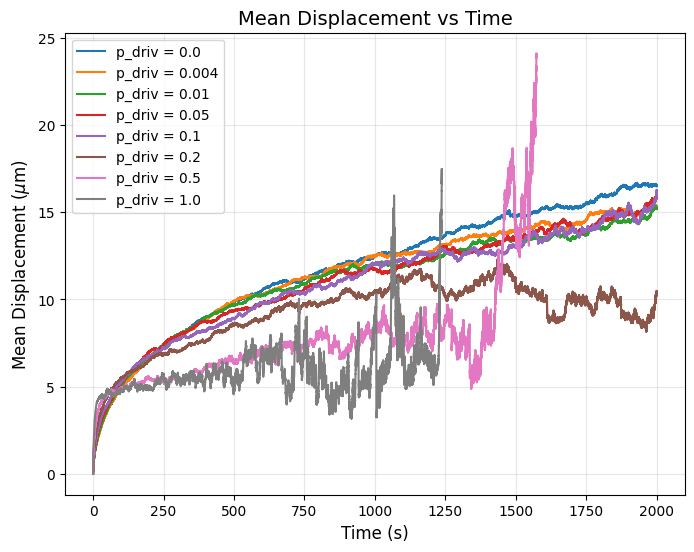

In [2]:
fig_disp, ax = analysis.plot_displacement_vs_time(
    p_driv_vals=[0.0, 0.004, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
    n_particles=1000,
    total_time=6000,
    dt=0.001,
    graph_cutoff=2000,
)
plt.show()

In [ ]:
fig, ax = analysis.plot_msd_vs_time(
    p_driv_vals=[0.0, 0.004, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
    n_particles=1000,
    total_time=6000,
    dt=0.001,
    graph_cutoff=2000,
)
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2825877822.py, line 5)

In [2]:
msd = np.zeros(int(1000 / 0.001 + 2))
particle_ct = np.zeros(int(1000 / 0.001 + 2))
for _ in range(10):
    config = sim.SimulationConfig(
        n_particles=1,
        total_time=1000,
        p_driv=0.004,
        end_early=False,
        dt=0.001,
    )

    # Run analysis to get MSD
    analysis_output = analysis.analyze(config)
    msd += np.pad(analysis_output.msd, (0, len(msd) - len(analysis_output.msd)), 'constant')
    particle_ct[:len(analysis_output.msd)] += 1

particle_ct[particle_ct == 0] = 1  # Prevent division by zero
msd /= particle_ct

# Create time axis
time = np.arange(len(msd)) * 0.001

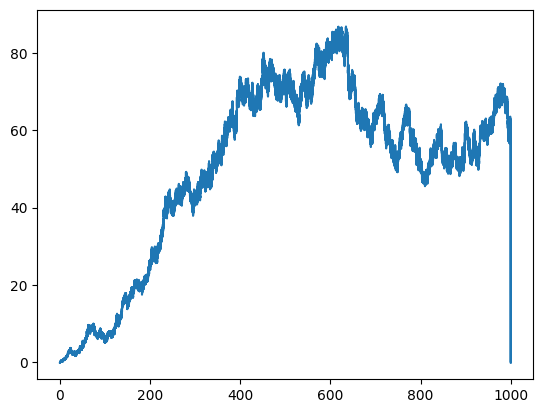

In [3]:
plt.plot(time, msd*1e12, label="p_driv=0.004")